## This notebook analyses and visualizes the nobel prize data from the kaggle competition. 

In [43]:
## Load the necessary libraries and modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [23]:
## Import the dataset
input_file_path = "/Users/iliyakwoji/Downloads/archive 2/complete.csv"
nobel_df = pd.read_csv(input_file_path)

nobel_df.head()

,awardYear,category,categoryFullName,sortOrder,portion,prizeAmount,prizeAmountAdjusted,dateAwarded,prizeStatus,motivation,...,org_founded_country,org_founded_countryNow,org_founded_locationString,ind_or_org,residence_1,residence_2,affiliation_1,affiliation_2,affiliation_3,affiliation_4
0,2001,Economic Sciences,The Sveriges Riksbank Prize in Economic Scienc...,2,1/3,10000000,12295082,2001-10-10,received,for their analyses of markets with asymmetric ...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Stanford University, Stanford, CA, USA",NaN,NaN,NaN
1,1975,Physics,The Nobel Prize in Physics,1,1/3,630000,3404179,1975-10-17,received,for the discovery of the connection between co...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Niels Bohr Institute, Copenhagen, Denmark",NaN,NaN,NaN
2,2004,Chemistry,The Nobel Prize in Chemistry,1,1/3,10000000,11762861,2004-10-06,received,for the discovery of ubiquitin-mediated protei...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Technion - Israel Institute of Technology, Hai...",NaN,NaN,NaN
3,1982,Chemistry,The Nobel Prize in Chemistry,1,1,1150000,3102518,1982-10-18,received,for his development of crystallographic electr...,...,NaN,NaN,NaN,Individual,NaN,NaN,"MRC Laboratory of Molecular Biology, Cambridge...",NaN,NaN,NaN
4,1979,Physics,The Nobel Prize in Physics,2,1/3,800000,2988048,1979-10-15,received,for their contributions to the theory of the u...,...,NaN,NaN,NaN,Individual,NaN,NaN,"International Centre for Theoretical Physics, ...","Imperial College, London, United Kingdom",NaN,NaN


In [24]:
# Exploring the dataset
nobel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   awardYear                   950 non-null    int64 
 1   category                    950 non-null    object
 2   categoryFullName            950 non-null    object
 3   sortOrder                   950 non-null    int64 
 4   portion                     950 non-null    object
 5   prizeAmount                 950 non-null    int64 
 6   prizeAmountAdjusted         950 non-null    int64 
 7   dateAwarded                 533 non-null    object
 8   prizeStatus                 950 non-null    object
 9   motivation                  950 non-null    object
 10  categoryTopMotivation       20 non-null     object
 11  award_link                  950 non-null    object
 12  id                          950 non-null    int64 
 13  name                        950 non-null    object

In [25]:
print(nobel_df["fullName"])

0                A. Michael Spence
1                  Aage Niels Bohr
2                Aaron Ciechanover
3                       Aaron Klug
4                      Abdus Salam
                  ...             
945                   John Bardeen
946             Linus Carl Pauling
947    Marie Curie, née Sklodowska
948                            NaN
949                            NaN
Name: fullName, Length: 950, dtype: object


### Analysing the Dataset

#### Which gender has has been awarded the most Nobel Prizes?

In [26]:
# Summarising the numerical column
nobel_df.describe()

,awardYear,sortOrder,prizeAmount,prizeAmountAdjusted,id
count,950.000000,950.000000,9.500000e+02,9.500000e+02,950.000000
mean,1971.207368,1.483158,3.460596e+06,6.145681e+06,483.043158
std,33.586969,0.688021,4.014530e+06,3.276874e+06,282.644711
min,1901.000000,1.000000,1.149350e+05,2.377268e+06,1.000000
25%,1947.000000,1.000000,1.703320e+05,3.052326e+06,238.250000
50%,1977.000000,1.000000,7.000000e+05,4.997406e+06,477.500000
75%,2000.000000,2.000000,8.000000e+06,9.044276e+06,727.750000
max,2019.000000,3.000000,1.000000e+07,1.229508e+07,984.000000


In [27]:
### Count the top gender 
gender_count = nobel_df["gender"].value_counts()

top_gender = gender_count.idxmax()

print(f'the top gender with most nobel prize winners is {top_gender}')

the top gender with most nobel prize winners is male


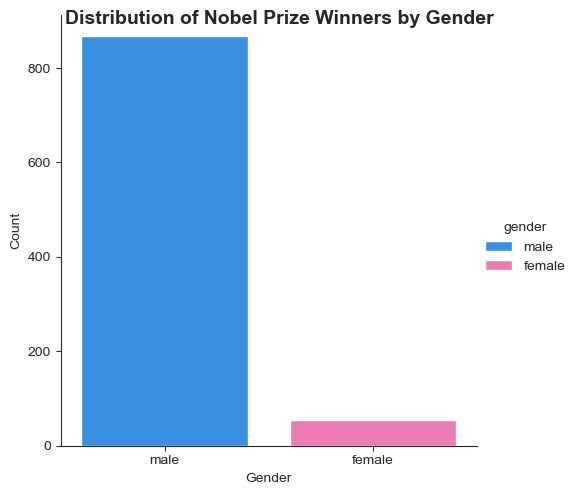

In [28]:
### Visualization of the gender distribution of Nobel Prize winners
sns.set_style("ticks")
colors = ["#1E90FF", "#FF69B4",]
f1 = sns.catplot(x="gender", data=nobel_df, kind="count", hue="gender", palette=colors)
f1.set_axis_labels("Gender", "Count")
f1.figure.suptitle("Distribution of Nobel Prize Winners by Gender", fontsize=14, fontweight="bold")
plt.show()

### What is the most common birth country of Nobel Prize laureates?

In [29]:
#print(nobel_df.columns)
# count the country with the most nobel prize winners
country_count = nobel_df["birth_country"].value_counts()

# Top country
top_country = country_count.idxmax()

print(f'the top country with most nobel prize winners is {top_country}')

the top country with most nobel prize winners is USA


### Plot the birth country with highest number of nobel laureates

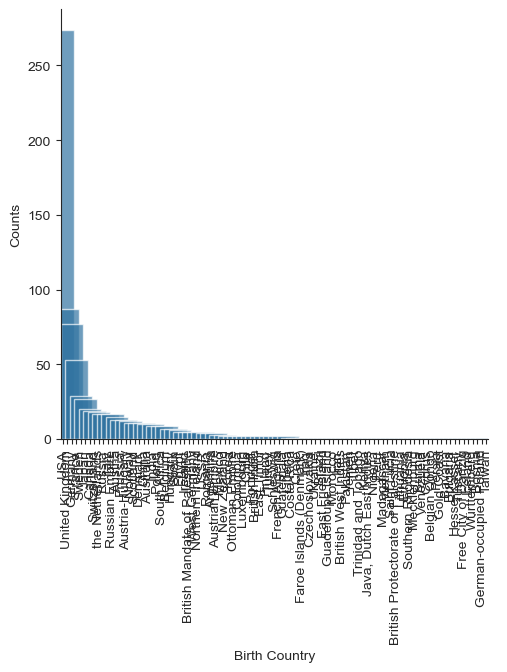

In [42]:
f2 = sns.catplot(data=nobel_df, x="birth_country", kind="count", width=5.0, alpha=0.7, order=country_count.index)
f2.set_xticklabels(rotation=90)
f2.set_axis_labels("Birth Country", "Counts")

plt.show()

### The previous plot is not very readable! Lets do a map plot using chloropleth



In [50]:
# plot of birth country split - chloropleth map plot
country_counts = nobel_df.value_counts("birth_country").reset_index() # number of prizes per country
country_counts.columns = ['Country', 'Counts'] #Rename cols for nice plots
f3 = px.choropleth(country_counts, 
                   locations="Country", 
                   locationmode="country names", 
                   color = "Counts",
                   color_continuous_scale="Turbo",
                   title="Number of Nobel Prize Winners by Country of Birth")
f3.update_layout(geo=dict(showframe=False, showcoastlines=True),
                 title_font_size=14,
                 title_font_weight="bold")
f3.update_traces(hovertemplate="%{location}<br>%{z}")
f3.show(renderer="iframe")
plt.show()

/var/folders/qn/f67z6b2j7mqgjgk8471s16bw0000gn/T/ipykernel_10972/231949883.py:4: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.

